In [69]:
# ================================
# Imports
# ================================

import torch
from torchvision import models, transforms
from PIL import Image
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
import torch.nn as nn

In [70]:
# ================================
# Device
# ================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [71]:
# ================================
# Load Class Labels
# ================================

TRAIN_DIR = "prototype_model/prototype_dataset_splitted/train"                                  ### TO BE CHANGED

train_data = ImageFolder(TRAIN_DIR)
classes = train_data.classes
print(f"Total classes: {len(classes)}")
print("Classes:", classes)

Total classes: 64
Classes: ['Abstract_Animal_Print_Dress', 'Abstract_Asymmetrical_Hem_Top', 'Abstract_Daisy_Print_Blouse', 'Abstract_Dotted_Dress', 'Abstract_Floral_Print_Dress', 'Abstract_Floral_Print_Maxi_Dress', 'Abstract_Grid_Print_Top', 'Abstract_Paisley_Print_Jumpsuit', 'Abstract_Stripe_Top', 'Abstract_V-Cut_Maxi_Dress', 'Abstract_Zippered_Crop_Top', 'Acid_Wash_Denim_Cutoffs', 'Anchor_Print_Shorts', 'Angel-Sleeved_Top', 'Arrow-Printed_Tee', 'Asymmetrical_Chiffon_Skirt', 'Asymmetrical_Pencil_Skirt', 'Bandana_Print_Layered_Tee', 'Barbie_Tank_Top', 'Baroque_Print_Crop_Top', 'Basic_V-Neck_Tee', 'Bell-Sleeved_Lace_Dress', 'Belted_Floral_Print_Dress', 'Big_Apples_Tee', 'Bird_Print_Kimono', 'Blah_Blah_Blah_Tee', 'Bleached_Denim_Jacket', 'Bleached_Low-Rise_Skinny_Jeans', 'Bob_Dylan_Graphic_Tee', 'Botanical_Print_Fit_&_Flare_Dress', 'Boxy_Faux_Fur_Jacket', 'Boyz_II_Men_Muscle_Tee', 'Brooklyn_Nets_Baseball_Tee', 'Brooklyn_Nets_Logo_Hoodie', 'Brooklyn_Nets_Logo_Sweatpants', 'Button-Down_Den

In [72]:
# ================================
# Model Setup
# ================================

"""
TRAIN_MODEL_TYPE = "resnet50"
1. resnet50_20251120_045757/best_model.pth => 99.92%
2. resnet50_20251119_132951/best_model.pth => 99.84%
3. resnet50_20251116_162404/dress_type_model_epoch_32_acc_99.84.pth => 99.84%
4. resnet50_20251116_081819/dress_type_model_epoch_24_acc_69.23.pth => 69.23%

TRAIN_MODEL_TYPE = "efficientnet_b3"
1. efficientnet_b3_20251119_081256/best_model.pth => 99.92%
2. efficientnet_b3_20251118_121426/best_model.pth => 99.92%
3. efficientnet_b3_20251117_183620/best_model.pth => 99.84%
"""

NUM_CLASSES = len(classes)                                                                      ### TO BE CHANGED
MODEL_PATH = "./prototype_model/prototype_trained_models/resnet50_20251120_045757/best_model.pth"          ### TO BE CHANGED
TRAIN_MODEL_TYPE = "resnet50"    ### resnet50 || efficientnet_b3

if TRAIN_MODEL_TYPE == "resnet50":
    model = models.resnet50(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, NUM_CLASSES)

elif TRAIN_MODEL_TYPE == "efficientnet_b3":
    model = efficientnet_b3(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

else:
    raise ValueError(f"Unknown model type: {TRAIN_MODEL_TYPE}")

try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
except FileNotFoundError:
    print(f"Model file not found: {MODEL_PATH}")

model = model.to(device)
model.eval()
print("Model loaded:", MODEL_PATH)

Model loaded: ./prototype_model/prototype_trained_models/resnet50_20251120_045757/best_model.pth


In [73]:
# ================================
# Image Transform
# ================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [74]:
# ================================
# Test Images Directory
# ================================

TEST_DIR = "test_images"                                                                        ### TO BE CHANGED
test_images = [os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR)
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'))]

print(f"Found {len(test_images)} test images.")

Found 8 test images.


In [75]:
# ================================
# Inference Loop
# ================================

predictions = []

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    inp = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(inp)
        _, pred = torch.max(output, 1)
        pred_class = classes[pred.item()]
    
    predictions.append((img, pred_class))
    print(f"{os.path.basename(img_path)} => Predicted: {pred_class}")

Abstract_Daisy_Print_Blouse_Test.png => Predicted: Abstract_Daisy_Print_Blouse
Abstract_Floral_Print_Maxi_Dress_Test.png => Predicted: Abstract_Floral_Print_Maxi_Dress
Anchor_Print_Shorts_Test.png => Predicted: Anchor_Print_Shorts
Bleached_Denim_Jacket_Test.png => Predicted: Bleached_Denim_Jacket
Brooklyn_Nets_Baseball_Tee_Test.png => Predicted: Brooklyn_Nets_Baseball_Tee
Cheetah_Print_High_Neck_Blouse_Test.png => Predicted: Cheetah_Print_High-Neck_Blouse
Daisy_Print_Maxi_Skirt_Test.png => Predicted: Daisy_Print_Maxi_Skirt
Slim_Fit_Moto_Jeans_Test.png => Predicted: Slim_Fit_Moto_Jeans


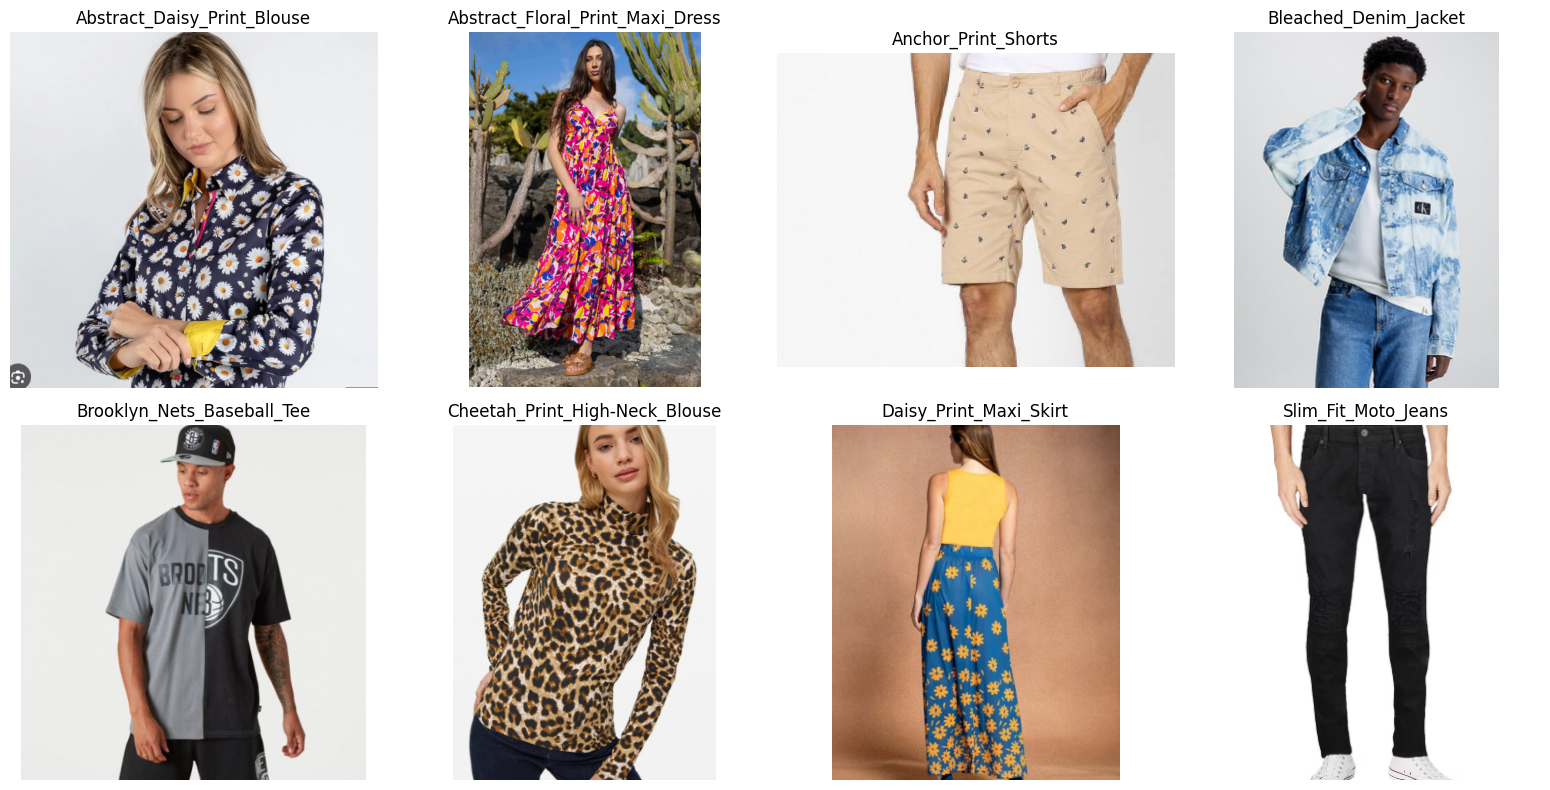

In [76]:
# ================================
# Display Images with Predictions
# ================================

num_cols = 4
num_rows = (len(predictions) + num_cols - 1) // num_cols
plt.figure(figsize=(4*num_cols, 4*num_rows))

for i, (img, pred_class) in enumerate(predictions):
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(img)
    plt.title(pred_class)
    plt.axis("off")

plt.tight_layout()
plt.show()